### Imports

In [11]:
from pathlib import Path
import json
import re
from typing import List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

import evaluate

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

TEST_CSV_PATH = Path("/workspace/RxHandBD-ML/Test_Label.csv")
TEST_IMG_DIR = Path("/workspace/RxHandBD-ML/Test_Set")

GEN_NUM_BEAMS = 1
GEN_MAX_LEN = 64
EVAL_BATCH = 4

OUTPUT_DIR = "outputs/trocr-diffbrush-trainer"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Helper Function just to get the best fine tuned checkpoint from the output folder

In [12]:
def resolve_best_checkpoint(output_dir: str) -> Path:
    """Resolve best fine-tuned checkpoint from trainer metadata, with fallbacks."""
    out = Path(output_dir)
    if not out.exists():
        raise FileNotFoundError(f"Output directory not found: {out.resolve()}")

    # 1) Root trainer_state.json (if present)
    state_path = out / "trainer_state.json"
    if state_path.exists():
        state = json.loads(state_path.read_text())
        best = state.get("best_model_checkpoint")
        if best:
            best_path = Path(best)
            if not best_path.is_absolute():
                best_path = out / best
            if best_path.exists():
                return best_path

    # 2) Newest checkpoint's trainer_state.json (if present)
    ckpt_states = sorted(
        out.glob("checkpoint-*/trainer_state.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    for cp_state in ckpt_states:
        try:
            state = json.loads(cp_state.read_text())
            best = state.get("best_model_checkpoint")
            if best:
                best_path = Path(best)
                if not best_path.is_absolute():
                    best_path = out / best
                if best_path.exists():
                    return best_path
        except Exception:
            pass

    # 3) Fallback to highest checkpoint-* step
    ckpts = [p for p in out.glob("checkpoint-*") if p.is_dir()]
    if ckpts:
        def _step_num(p: Path) -> int:
            m = re.search(r"checkpoint-(\d+)", p.name)
            return int(m.group(1)) if m else -1

        return max(ckpts, key=lambda p: (_step_num(p), p.stat().st_mtime))

    # 4) Last resort: output dir itself (if save_model(OUTPUT_DIR) exists)
    cfg = out / "config.json"
    if cfg.exists():
        return out

    raise FileNotFoundError(
        f"No checkpoint found in {out.resolve()} (no trainer_state.json/checkpoint-*/config.json)."
    )

### Resolve artifacts and test data

In [13]:

best_ckpt = resolve_best_checkpoint(OUTPUT_DIR)
print(f"Using fine-tuned checkpoint: {best_ckpt}")

test_csv, test_img_dir = TEST_CSV_PATH, TEST_IMG_DIR
print(f"Using test CSV: {test_csv}")
print(f"Using test image dir: {test_img_dir}")

test_df = pd.read_csv(test_csv)
test_df.columns = test_df.columns.str.strip()
assert {"Images", "Text"}.issubset(test_df.columns), "Test CSV must contain Images and Text columns"

Using fine-tuned checkpoint: outputs/trocr-diffbrush-trainer/checkpoint-20540
Using test CSV: /workspace/RxHandBD-ML/Test_Label.csv
Using test image dir: /workspace/RxHandBD-ML/Test_Set


### Aligning the Model to the Processor

In [14]:
def align_model_to_processor(model, processor):
    tokenizer = processor.tokenizer

    model.config.decoder_start_token_id = tokenizer.cls_token_id
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.sep_token_id

    model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.sep_token_id

    # Useful for generation later
    model.generation_config.max_length = 64
    model.generation_config.num_beams = 1

    return model

### Testing Metrics

In [15]:
def normalize_text_batch(texts: List[str]) -> List[str]:
    return [str(t).strip() for t in texts]


def sequence_accuracy(refs: List[str], preds: List[str]) -> float:
    return float(np.mean([r == p for r, p in zip(refs, preds)])) if refs else 0.0


def word_edit_distance(ref: str, hyp: str) -> int:
    """Levenshtein edit distance on whitespace-tokenized words."""
    a = ref.split()
    b = hyp.split()
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost,
            )
    return dp[m][n]


def per_line_word_error_counts(refs: List[str], preds: List[str]) -> List[int]:
    return [word_edit_distance(r, p) for r, p in zip(refs, preds)]

### Model Evaluation Function

In [16]:
def evaluate_model_on_test(
    model: VisionEncoderDecoderModel,
    processor: TrOCRProcessor,
    test_df: pd.DataFrame,
    test_img_dir: Path,
    batch_size: int = 4,
    num_beams: Optional[int] = None,
    max_length: Optional[int] = None,
) -> dict:
    model.eval()
    model.to(device)

    num_beams = GEN_NUM_BEAMS if num_beams is None else num_beams
    max_length = GEN_MAX_LEN if max_length is None else max_length

    names = test_df["Images"].astype(str).tolist()
    paths = [str(test_img_dir / n) for n in names]
    refs = test_df["Text"].astype(str).tolist()

    preds: List[str] = []

    with torch.no_grad():
        for i in range(0, len(names), batch_size):
            batch_names = names[i : i + batch_size]
            images = [Image.open(test_img_dir / n).convert("RGB") for n in batch_names]

            pixel_values = processor(images=images, return_tensors="pt").pixel_values.to(device)
            out_ids = model.generate(
                pixel_values,
                num_beams=num_beams,
                max_length=max_length,
                early_stopping=True,
            )
            out_text = processor.batch_decode(out_ids, skip_special_tokens=True)
            preds.extend(out_text)

    refs = normalize_text_batch(refs)
    preds = normalize_text_batch(preds)

    return {
        "refs": refs,
        "preds": preds,
        "paths": paths,
        "wer": float(wer_metric.compute(predictions=preds, references=refs)),
        "cer": float(cer_metric.compute(predictions=preds, references=refs)),
        "seq_acc": sequence_accuracy(refs, preds),
        "n_samples": len(refs),
    }

### Base Model

In [17]:
# Evaluate base model
base_name = "microsoft/trocr-base-handwritten"
proc_base = TrOCRProcessor.from_pretrained(base_name)
mdl_base = VisionEncoderDecoderModel.from_pretrained(base_name).to(device)
mdl_base = align_model_to_processor(mdl_base, proc_base)

res_base = evaluate_model_on_test(
    mdl_base,
    proc_base,
    test_df,
    test_img_dir,
    batch_size=EVAL_BATCH,
    num_beams=GEN_NUM_BEAMS,
    max_length=GEN_MAX_LEN,
)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Evaluate fine-tuned best checkpoint

In [18]:

proc_ft = TrOCRProcessor.from_pretrained(best_ckpt)
mdl_ft = VisionEncoderDecoderModel.from_pretrained(best_ckpt).to(device)
mdl_ft = align_model_to_processor(mdl_ft, proc_ft)

res_ft = evaluate_model_on_test(
    mdl_ft,
    proc_ft,
    test_df,
    test_img_dir,
    batch_size=EVAL_BATCH,
    num_beams=GEN_NUM_BEAMS,
    max_length=GEN_MAX_LEN,
)


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

### Figures

            Model      WER      CER  Line acc (exact)  n (test)
base (pretrained) 1.751011 0.760683          0.080717      1115
fine-tuned (best) 0.885206 0.564778          0.131839      1115

Delta (base - fine)  WER: 0.865804  CER: 0.195904


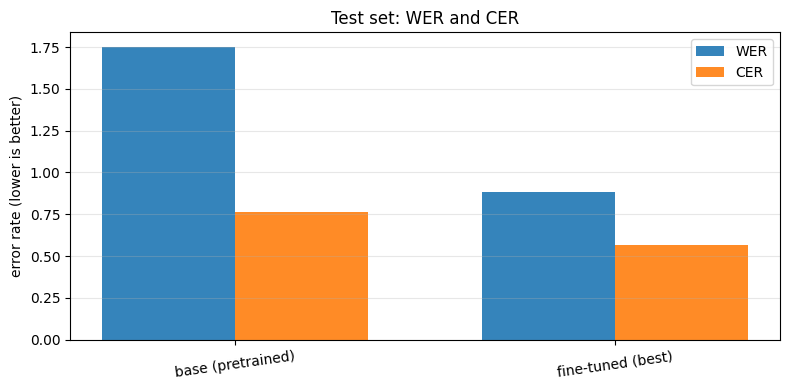

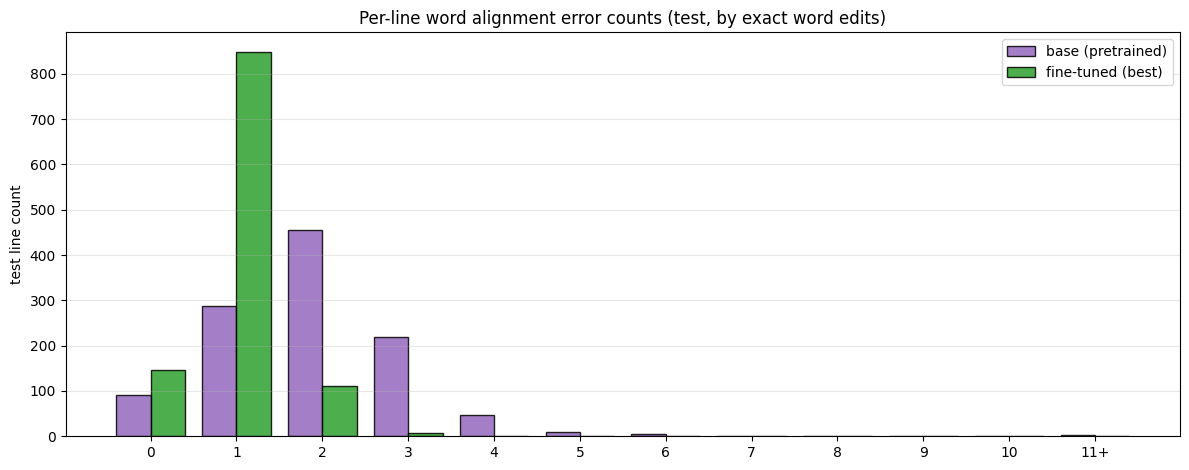

Bucket totals check - base: 1115 / 1115
Bucket totals check - fine: 1115 / 1115


In [19]:
# Summary table
summary = pd.DataFrame(
    {
        "Model": ["base (pretrained)", "fine-tuned (best)"],
        "WER": [res_base["wer"], res_ft["wer"]],
        "CER": [res_base["cer"], res_ft["cer"]],
        "Line acc (exact)": [res_base["seq_acc"], res_ft["seq_acc"]],
        "n (test)": [res_base["n_samples"], res_ft["n_samples"]],
    }
)
print(summary.to_string(index=False))
print()
print(
    "Delta (base - fine)  WER:",
    round(res_base["wer"] - res_ft["wer"], 6),
    " CER:",
    round(res_base["cer"] - res_ft["cer"], 6),
)

# Plot 1: grouped bar for WER/CER by model
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, [res_base["wer"], res_ft["wer"]], w, label="WER", color="C0", alpha=0.9)
ax.bar(x + w / 2, [res_base["cer"], res_ft["cer"]], w, label="CER", color="C1", alpha=0.9)
ax.set_xticks(x, ["base (pretrained)", "fine-tuned (best)"], rotation=8)
ax.set_ylabel("error rate (lower is better)")
ax.set_title("Test set: WER and CER")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: grouped bar for per-line word edit buckets (0..10 and 11+)
ops_base = per_line_word_error_counts(res_base["refs"], res_base["preds"])
ops_ft = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])

max_bucket = 10
labels = [str(i) for i in range(max_bucket + 1)] + [f"{max_bucket + 1}+"]

base_bins = [sum(1 for e in ops_base if e == i) for i in range(max_bucket + 1)]
base_bins.append(sum(1 for e in ops_base if e >= max_bucket + 1))

ft_bins = [sum(1 for e in ops_ft if e == i) for i in range(max_bucket + 1)]
ft_bins.append(sum(1 for e in ops_ft if e >= max_bucket + 1))

x2 = np.arange(len(labels))
w2 = 0.40

fig2, ax2 = plt.subplots(figsize=(12, 4.8))
ax2.bar(x2 - w2 / 2, base_bins, w2, label="base (pretrained)", color="C4", edgecolor="black", alpha=0.85)
ax2.bar(x2 + w2 / 2, ft_bins, w2, label="fine-tuned (best)", color="C2", edgecolor="black", alpha=0.85)
ax2.set_xticks(x2, labels)
ax2.set_ylabel("test line count")
ax2.set_title("Per-line word alignment error counts (test, by exact word edits)")
ax2.legend()
ax2.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bucket totals check - base: {sum(base_bins)} / {res_base['n_samples']}")
print(f"Bucket totals check - fine: {sum(ft_bins)} / {res_ft['n_samples']}")

### Hard Examples

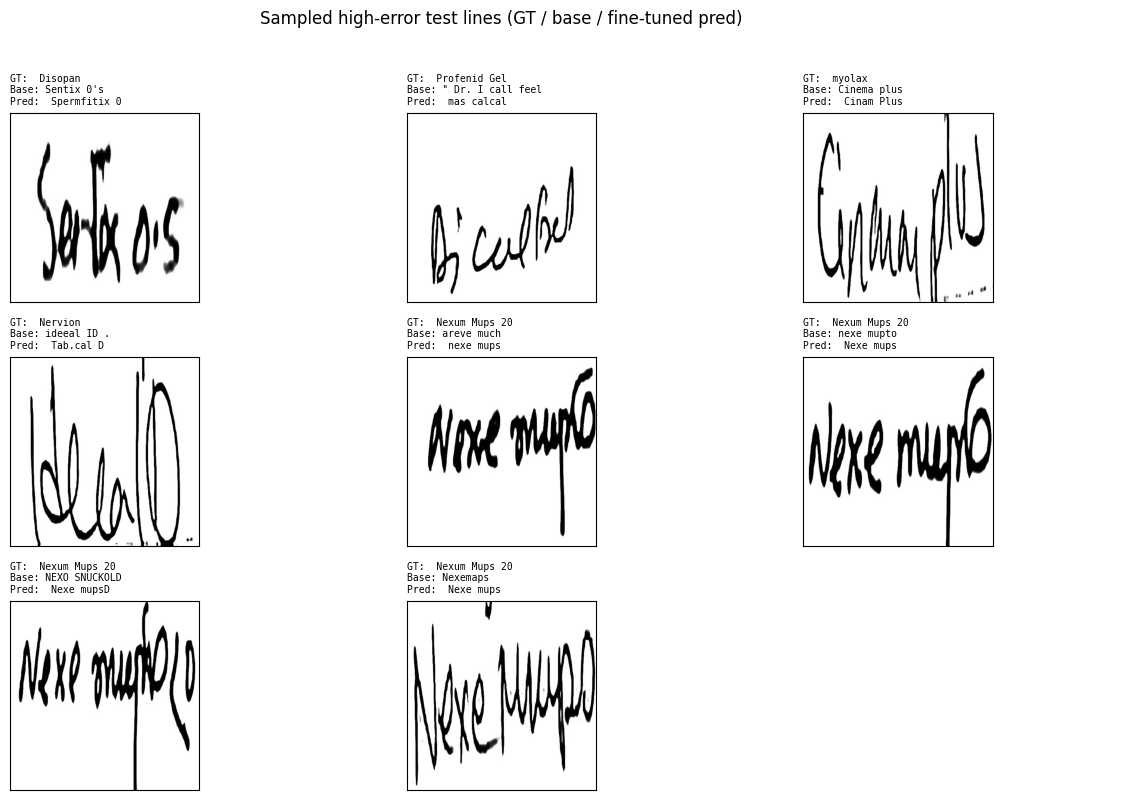

In [20]:
import random

# Hard examples: sort mistakes by word ops, then sample with a fixed seed
HARD_N = 8
HARD_SEED = 7
rng = random.Random(HARD_SEED)

ops = per_line_word_error_counts(res_ft["refs"], res_ft["preds"])
wrong = [i for i, (r, p) in enumerate(zip(res_ft["refs"], res_ft["preds"])) if r != p]
wrong.sort(key=lambda j: -ops[j])
cand = wrong[: max(3 * HARD_N, HARD_N)]
pick = rng.sample(cand, k=min(HARD_N, len(cand))) if cand else []
pick.sort()

if not pick:
    print("No incorrect predictions on the test set to display.")
else:
    nc, nr = 3, int(np.ceil(len(pick) / 3))
    fig, axes = plt.subplots(nr, nc, figsize=(4.2 * nc, 2.6 * nr))
    axes = np.array(axes).ravel()
    for k, ax in enumerate(axes):
        if k >= len(pick):
            ax.axis("off")
            continue
        j = pick[k]
        im = Image.open(res_ft["paths"][j]).convert("RGB")
        ax.imshow(im)
        t = f"GT:  {res_ft['refs'][j]}\nBase: {res_base['preds'][j]}\nPred:  {res_ft['preds'][j]}"
        ax.set_title(t, fontsize=7, family="monospace", loc="left")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.suptitle("Sampled high-error test lines (GT / base / fine-tuned pred)", y=1.02)
    plt.tight_layout()
    plt.show()
